In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Load the 4 cleaned files
df_orders = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/orders.parquet")
df_items = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/order_items.parquet")
df_customers = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/customers.parquet")
df_products = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/products.parquet")


In [11]:

# Join all 4 tables together at the order-item grain
df_master = (
    df_items.merge(df_orders, on="order_id", how="inner")
    .merge(df_customers, on="customer_id", how="inner")
    .merge(df_products, on="product_id", how="inner")
)

# Filter strictly to delivered orders for accurate operational/sales metrics
df_master = df_master[df_master["order_status"] == "delivered"].copy()


In [12]:
# Feature Engineering: Fulfillment & Total Value
df_master["total_item_value"] = df_master["price"] + df_master["freight_value"]
df_master["delivery_lead_time_days"] = (
    df_master["order_delivered_customer_date"] - df_master["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)
df_master["order_month"] = df_master["order_purchase_timestamp"].dt.to_period("M")

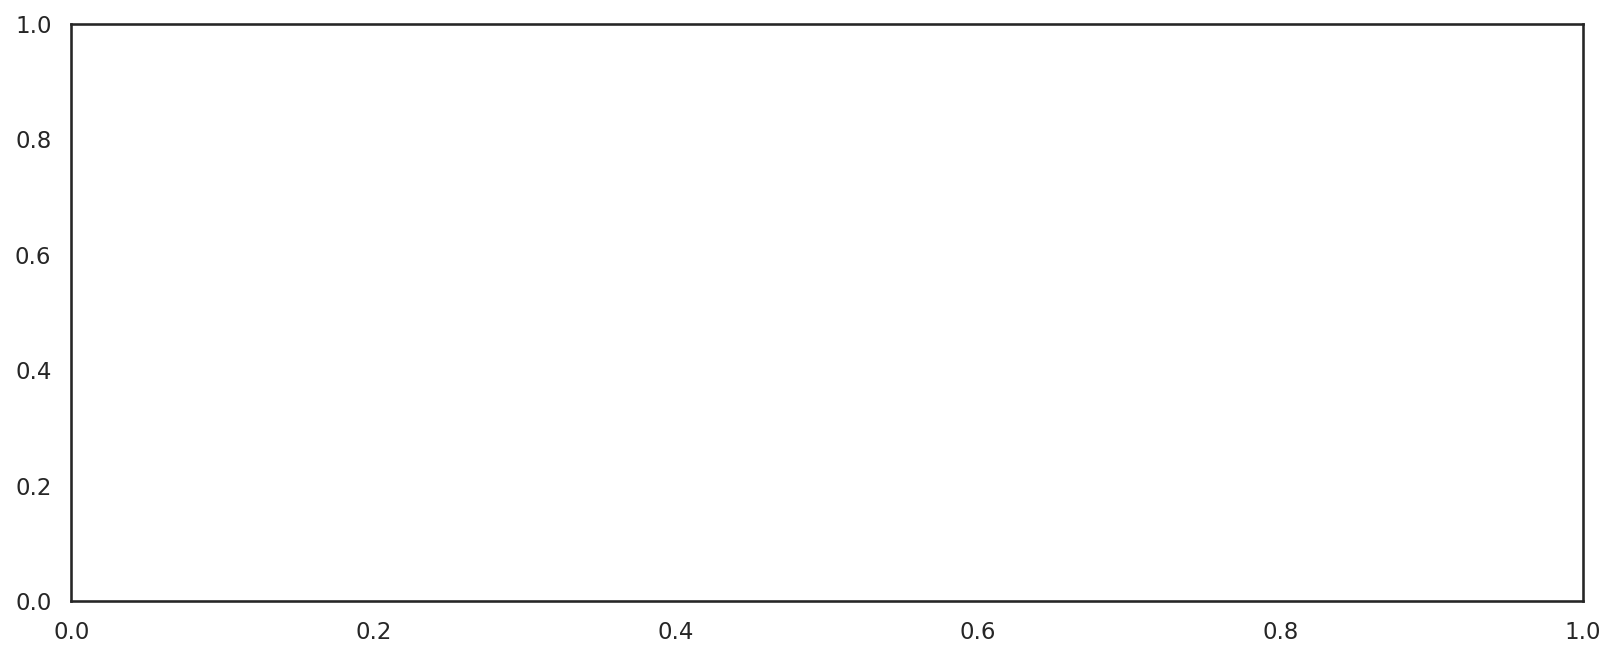

In [13]:
# MONTHLY REVENUE & ORDER VOLUME

monthly_perf = df_master.groupby("order_month").agg(
    total_revenue=("total_item_value", "sum"),
    order_volume=("order_id", "nunique")
).reset_index()
monthly_perf["order_month_str"] = monthly_perf["order_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(13, 5), dpi=150)

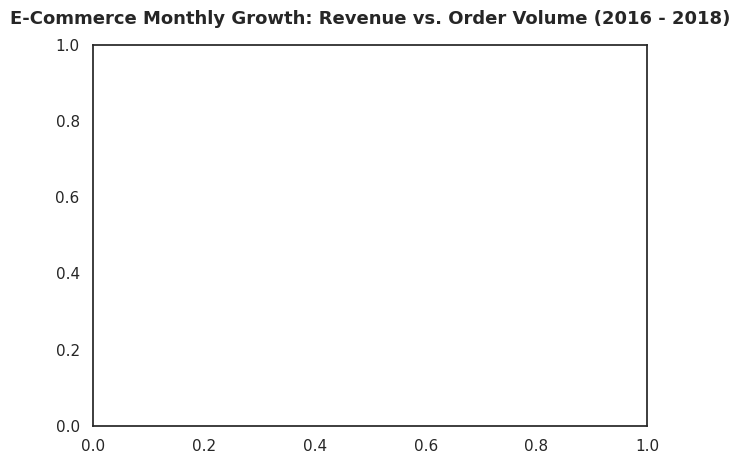

In [14]:
# Bar chart: Revenue
ax1.bar(
    monthly_perf["order_month_str"],
    monthly_perf["total_revenue"] / 1000,
    color="#2b5c8f",
    alpha=0.85,
    label="Gross Revenue (k BRL)"
)
ax1.set_ylabel("Revenue in Thousands (BRL)", color="#2b5c8f", fontsize=11, fontweight="bold")
ax1.tick_params(axis="x", rotation=45)

# Line chart: Order Volume
ax2 = ax1.twinx()
ax2.plot(
    monthly_perf["order_month_str"],
    monthly_perf["order_volume"],
    color="#d95f02",
    linewidth=2.5,
    marker="o",
    label="Unique Orders"
)
ax2.set_ylabel("Order Count", color="#d95f02", fontsize=11, fontweight="bold")
ax2.grid(False)

plt.title("E-Commerce Monthly Growth: Revenue vs. Order Volume (2016 - 2018)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/eda_monthly_sales_trend.png")
plt.show()

In [15]:
# TOP 10 PRODUCT CATEGORIES BY REVENUE & AOV

top_cats = (
    df_master.groupby("category_name")
    .agg(
        total_revenue=("total_item_value", "sum"),
        order_count=("order_id", "nunique")
    )
    .assign(aov=lambda x: x["total_revenue"] / x["order_count"])
    .sort_values(by="total_revenue", ascending=False)
    .head(10)
    .reset_index()
)

/tmp/ipykernel_1887/209760670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


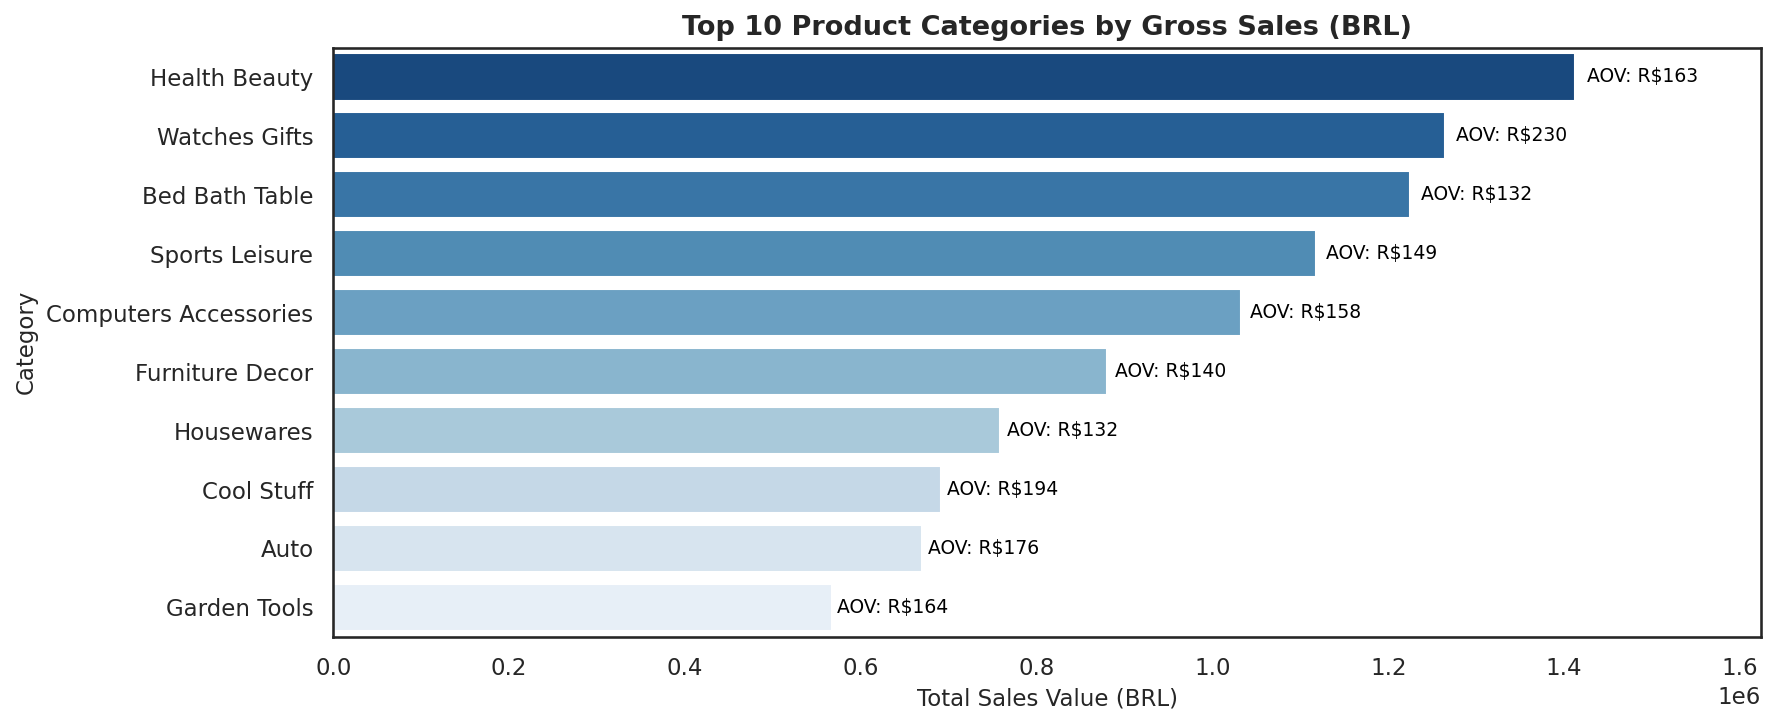

In [16]:
plt.figure(figsize=(12, 5), dpi=150)
bars = sns.barplot(
    data=top_cats,
    x="total_revenue",
    y="category_name",
    palette="Blues_r"
)
plt.title("Top 10 Product Categories by Gross Sales (BRL)", fontsize=13, fontweight="bold")
plt.xlabel("Total Sales Value (BRL)", fontsize=11)
plt.ylabel("Category", fontsize=11)

# Annotate bars with Average Order Value (AOV)
for index, row in top_cats.iterrows():
    bars.text(
        row["total_revenue"] * 1.01,
        index,
        f"AOV: R${row['aov']:.0f}",
        color="black",
        va="center",
        fontsize=9
    )

plt.xlim(0, top_cats["total_revenue"].max() * 1.15)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/eda_top_categories_aov.png")
plt.show()

In [17]:
# REGIONAL FULFILLMENT BOTTLENECK (LOGISTICS LAG)
state_logistics = (
    df_master.groupby("customer_state")
    .agg(
        avg_delivery_days=("delivery_lead_time_days", "mean"),
        total_orders=("order_id", "nunique")
    )
    .query("total_orders > 100") # Filter for statistically significant states
    .sort_values(by="avg_delivery_days", ascending=False)
    .reset_index()
)

/tmp/ipykernel_1887/441215389.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


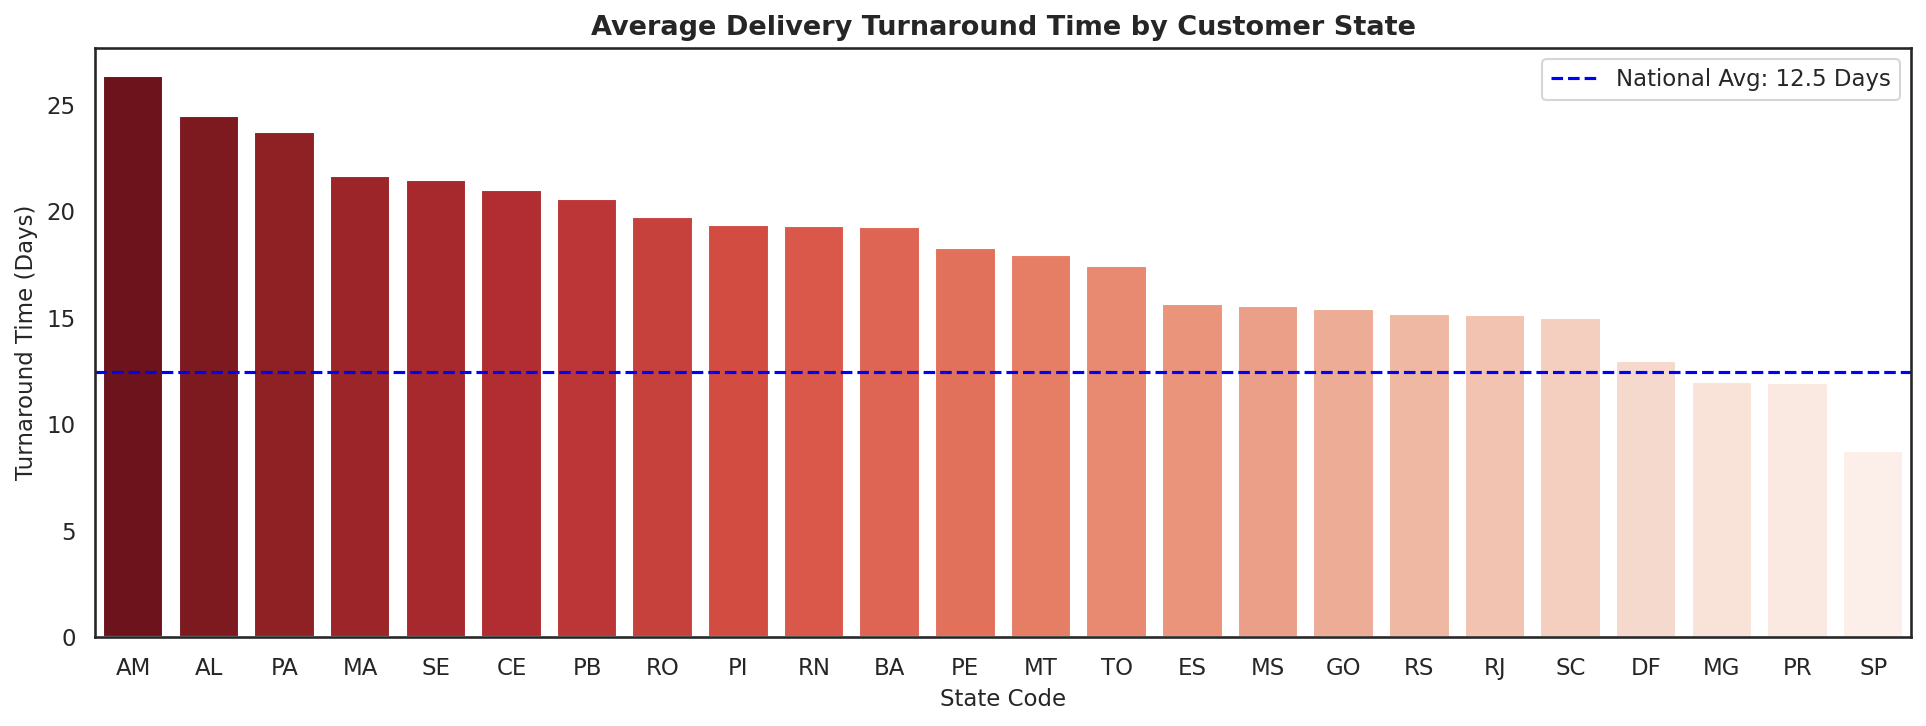

In [18]:
plt.figure(figsize=(13, 5), dpi=150)
sns.barplot(
    data=state_logistics,
    x="customer_state",
    y="avg_delivery_days",
    palette="Reds_r"
)
plt.axhline(
    df_master["delivery_lead_time_days"].mean(),
    color="blue",
    linestyle="--",
    linewidth=1.5,
    label=f"National Avg: {df_master['delivery_lead_time_days'].mean():.1f} Days"
)
plt.title("Average Delivery Turnaround Time by Customer State", fontsize=13, fontweight="bold")
plt.xlabel("State Code", fontsize=11)
plt.ylabel("Turnaround Time (Days)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/eda_logistics_by_state.png")
plt.show()